# Import Requires Python libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Raw Sales Datasets which was Downloaded from Kaggle

In [2]:
df=pd.read_excel(r"C:\Users\manda\Desktop\kaggle Dataset\Sales_Data.csv")

# View Datasets

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,STD,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,Tenex Lockers,408,2,0.0,106.140,35.46,Medium,2011
1,AG-2011-2040,2011-01-01,2011-01-06,STD,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,Blue,408,2,0.0,106.140,35.46,Medium,2011
2,IN-2011-47883,2011-01-01,2011-01-08,STD,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,Acme Trimmer,120,3,0.1,36.036,9.72,Medium,2011
3,IN-2011-47883,2011-01-01,2011-01-08,STD,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,High Speed,120,3,0.1,36.036,9.72,Medium,2011
4,HU-2011-1220,2011-01-01,2011-01-05,S_Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,Tenex Box,66,4,0.0,29.640,8.17,High,2011


# Check Columns data types 

In [4]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

# Check Duplicate records, if Available Immediate Remove it

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates()# if available

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,STD,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,Tenex Lockers,408,2,0.0,106.1400,35.46,Medium,2011
1,AG-2011-2040,2011-01-01,2011-01-06,STD,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,Blue,408,2,0.0,106.1400,35.46,Medium,2011
2,IN-2011-47883,2011-01-01,2011-01-08,STD,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,Acme Trimmer,120,3,0.1,36.0360,9.72,Medium,2011
3,IN-2011-47883,2011-01-01,2011-01-08,STD,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,High Speed,120,3,0.1,36.0360,9.72,Medium,2011
4,HU-2011-1220,2011-01-01,2011-01-05,S_Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,Tenex Box,66,4,0.0,29.6400,8.17,High,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95701,MX-2014-110527,2014-12-31,2015-01-02,S_Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,Hon Color Coded Labels,26,3,0.0,12.3600,0.35,Medium,2014
95702,MX-2014-110527,2014-12-31,2015-01-02,S_Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,5000 Label Set,26,3,0.0,12.3600,0.35,Medium,2014
95703,MX-2014-114783,2014-12-31,2015-01-06,STD,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,Hon Legal Exhibit Labels,7,1,0.0,0.5600,0.20,Medium,2014
95704,MX-2014-114783,2014-12-31,2015-01-06,STD,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,Alphabetical,7,1,0.0,0.5600,0.20,Medium,2014


# Dimension of datasets

In [7]:
df.shape

(95706, 21)

# Check Missing Values, if available ,handle it witrh the help of 'fillna','dropna'.

In [8]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      7
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

#### Only product_name Column has 7 missing value. i want to replacedwith mode.    

In [9]:
df['product_name']=df['product_name'].fillna(df['product_name'].mode()[0])

In [10]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

#### Now Datasets has no missing values, no duplicates Records.

# Check Outlies.

## a. Boxplot

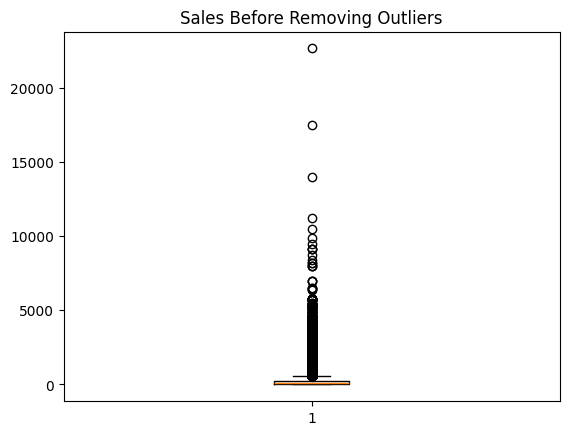

In [11]:
import matplotlib.pyplot as plt

plt.boxplot(df['sales'])
plt.title("Sales Before Removing Outliers")
plt.show()

# Extract Month, Day, Weekday and Quarter for Better sales_forecasting ML Models.

In [12]:
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['weekday'] = df['order_date'].dt.dayofweek
df['quarter'] = df['order_date'].dt.quarter

In [13]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,month,day,weekday,quarter
0,AG-2011-2040,2011-01-01,2011-01-06,STD,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,1,1,5,1
1,AG-2011-2040,2011-01-01,2011-01-06,STD,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,1,1,5,1
2,IN-2011-47883,2011-01-01,2011-01-08,STD,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,1,1,5,1
3,IN-2011-47883,2011-01-01,2011-01-08,STD,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,1,1,5,1
4,HU-2011-1220,2011-01-01,2011-01-05,S_Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,4,0.0,29.640,8.17,High,2011,1,1,5,1


In [14]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
month                      int32
day                        int32
weekday                    int32
quarter                    int32
dtype: object

# Sort the values for time series forecasting and trained by past data, testing by latest data.

In [15]:
df = df.sort_values('order_date')

# Select important and meaningful features for sales forecast , remove noise features.

In [16]:
selected_cols = [
    'segment',
    'market',
    'region',
    'category',
    'sub_category',
    'quantity',
    'discount',
    'profit',
    'shipping_cost',
    'order_priority',
    'year',
    'month',
    'weekday',
    'quarter',
    'sales'
]

df = df[selected_cols]

In [17]:
df['sales'].max()

np.int64(22638)

In [18]:
df

,segment,market,region,category,sub_category,quantity,discount,profit,shipping_cost,order_priority,year,month,weekday,quarter,sales
0,Consumer,Africa,Africa,Office Supplies,Storage,2,0.0,106.1400,35.46,Medium,2011,1,5,1,408
11,Consumer,APAC,Oceania,Office Supplies,Paper,2,0.1,15.3420,1.80,Medium,2011,1,5,1,55
9,Consumer,APAC,Oceania,Furniture,Furnishings,5,0.1,37.7700,4.70,Medium,2011,1,5,1,114
8,Consumer,APAC,Oceania,Furniture,Furnishings,5,0.1,37.7700,4.70,Medium,2011,1,5,1,114
7,Home Office,EU,North,Office Supplies,Paper,3,0.5,-26.0550,4.82,High,2011,1,5,1,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95618,Home Office,EU,Central,Technology,Machines,3,0.5,-19.3950,22.09,High,2014,12,2,4,108
95617,Consumer,APAC,North Asia,Technology,Accessories,3,0.0,84.0600,23.96,Medium,2014,12,2,4,300
95616,Consumer,APAC,North Asia,Technology,Accessories,3,0.0,84.0600,23.96,Medium,2014,12,2,4,300
95644,Home Office,US,Central,Office Supplies,Appliances,2,0.0,56.5110,8.32,Medium,2014,12,2,4,209


In [19]:
df.dtypes

segment            object
market             object
region             object
category           object
sub_category       object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
month               int32
weekday             int32
quarter             int32
sales               int64
dtype: object

# Encode important text column into Numerical Coumns.

In [20]:
cat_cols = [
    'segment',
    'market',
    'region',
    'category',
    'sub_category',
    'order_priority'
]

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [21]:
df.head()

,quantity,discount,profit,shipping_cost,year,month,weekday,quarter,sales,segment_Corporate,...,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium
0,2,0.0,106.140,35.46,2011,1,5,1,408,False,...,False,False,False,False,True,False,False,False,False,True
11,2,0.1,15.342,1.80,2011,1,5,1,55,False,...,False,False,True,False,False,False,False,False,False,True
9,5,0.1,37.770,4.70,2011,1,5,1,114,False,...,False,False,False,False,False,False,False,False,False,True
8,5,0.1,37.770,4.70,2011,1,5,1,114,False,...,False,False,False,False,False,False,False,False,False,True
7,3,0.5,-26.055,4.82,2011,1,5,1,45,False,...,False,False,True,False,False,False,False,True,False,False


In [22]:
df.dtypes

quantity                      int64
discount                    float64
profit                      float64
shipping_cost               float64
year                          int64
month                         int32
weekday                       int32
quarter                       int32
sales                         int64
segment_Corporate              bool
segment_Home Office            bool
market_Africa                  bool
market_Canada                  bool
market_EMEA                    bool
market_EU                      bool
market_LATAM                   bool
market_US                      bool
region_Canada                  bool
region_Caribbean               bool
region_Central                 bool
region_Central Asia            bool
region_EMEA                    bool
region_East                    bool
region_North                   bool
region_North Asia              bool
region_Oceania                 bool
region_South                   bool
region_Southeast Asia       

# Convert all 'int' type Columns.

In [23]:
df = df.astype(int, errors='ignore')

In [24]:
df.dtypes

quantity                    int64
discount                    int64
profit                      int64
shipping_cost               int64
year                        int64
month                       int64
weekday                     int64
quarter                     int64
sales                       int64
segment_Corporate           int64
segment_Home Office         int64
market_Africa               int64
market_Canada               int64
market_EMEA                 int64
market_EU                   int64
market_LATAM                int64
market_US                   int64
region_Canada               int64
region_Caribbean            int64
region_Central              int64
region_Central Asia         int64
region_EMEA                 int64
region_East                 int64
region_North                int64
region_North Asia           int64
region_Oceania              int64
region_South                int64
region_Southeast Asia       int64
region_West                 int64
category_Offic

# Save the Clean datasets before Splitting 

In [25]:
df.to_csv('Sales_forecast_data_ML.csv',index=False)

# Select input and target features.

In [26]:
x = df.drop('sales', axis=1)
y = df['sales']

## a. Input: x

In [27]:
x

,quantity,discount,profit,shipping_cost,year,month,weekday,quarter,segment_Corporate,segment_Home Office,...,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium
0,2,0,106,35,2011,1,5,1,0,0,...,0,0,0,0,1,0,0,0,0,1
11,2,0,15,1,2011,1,5,1,0,0,...,0,0,1,0,0,0,0,0,0,1
9,5,0,37,4,2011,1,5,1,0,0,...,0,0,0,0,0,0,0,0,0,1
8,5,0,37,4,2011,1,5,1,0,0,...,0,0,0,0,0,0,0,0,0,1
7,3,0,-26,4,2011,1,5,1,0,1,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95618,3,0,-19,22,2014,12,2,4,0,1,...,0,1,0,0,0,0,0,1,0,0
95617,3,0,84,23,2014,12,2,4,0,0,...,0,0,0,0,0,0,0,0,0,1
95616,3,0,84,23,2014,12,2,4,0,0,...,0,0,0,0,0,0,0,0,0,1
95644,2,0,56,8,2014,12,2,4,0,1,...,0,0,0,0,0,0,0,0,0,1


## b. Target:y

In [28]:
y

0        408
11        55
9        114
8        114
7         45
        ... 
95618    108
95617    300
95616    300
95644    209
95705      3
Name: sales, Length: 95706, dtype: int64

# Train- Test Spilt 

In [29]:
split_index = int(len(df) * 0.80)

x_train = x[:split_index]
x_test = x[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Training datasets 

In [30]:
x_train

,quantity,discount,profit,shipping_cost,year,month,weekday,quarter,segment_Corporate,segment_Home Office,...,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium
0,2,0,106,35,2011,1,5,1,0,0,...,0,0,0,0,1,0,0,0,0,1
11,2,0,15,1,2011,1,5,1,0,0,...,0,0,1,0,0,0,0,0,0,1
9,5,0,37,4,2011,1,5,1,0,0,...,0,0,0,0,0,0,0,0,0,1
8,5,0,37,4,2011,1,5,1,0,0,...,0,0,0,0,0,0,0,0,0,1
7,3,0,-26,4,2011,1,5,1,0,1,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76529,1,0,57,29,2014,7,4,3,0,1,...,0,0,0,0,1,0,0,0,0,1
76528,2,0,125,32,2014,7,4,3,1,0,...,0,0,0,0,0,0,1,0,0,1
76527,2,0,125,32,2014,7,4,3,1,0,...,0,0,0,0,0,0,1,0,0,1
76526,3,0,115,39,2014,7,4,3,1,0,...,0,0,0,0,0,0,0,0,0,1


In [31]:
y_train

0        408
11        55
9        114
8        114
7         45
        ... 
76529    205
76528    360
76527    360
76526    504
76556     78
Name: sales, Length: 76564, dtype: int64

# Testing datasets

In [32]:
x_test

,quantity,discount,profit,shipping_cost,year,month,weekday,quarter,segment_Corporate,segment_Home Office,...,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium
76524,2,0,68,39,2014,7,4,3,1,0,...,0,1,0,0,0,0,0,0,0,1
76523,2,0,68,39,2014,7,4,3,1,0,...,0,1,0,0,0,0,0,0,0,1
76531,3,0,-43,26,2014,7,4,3,0,1,...,0,0,0,0,0,0,0,0,0,1
76522,8,0,122,51,2014,7,4,3,0,0,...,0,0,0,0,1,0,0,0,0,1
76520,3,0,34,56,2014,7,4,3,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95618,3,0,-19,22,2014,12,2,4,0,1,...,0,1,0,0,0,0,0,1,0,0
95617,3,0,84,23,2014,12,2,4,0,0,...,0,0,0,0,0,0,0,0,0,1
95616,3,0,84,23,2014,12,2,4,0,0,...,0,0,0,0,0,0,0,0,0,1
95644,2,0,56,8,2014,12,2,4,0,1,...,0,0,0,0,0,0,0,0,0,1


In [33]:
y_test

76524     530
76523     530
76531     286
76522    1023
76520     342
         ... 
95618     108
95617     300
95616     300
95644     209
95705       3
Name: sales, Length: 19142, dtype: int64

# Model selections( Multiple Linear Regression) and fit the model using traning datasets.

In [34]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Testing model using 'x_test'.

In [35]:
y_pred=model.predict(x_test)

# Model Prediction values based on Training datasets.

In [36]:
y_pred

array([447.25444224, 447.25444224, 341.3842739 , ..., 285.34424999,
       301.46246108,  20.92432913], shape=(19142,))

In [37]:
y_test

76524     530
76523     530
76531     286
76522    1023
76520     342
         ... 
95618     108
95617     300
95616     300
95644     209
95705       3
Name: sales, Length: 19142, dtype: int64

# Calculates Model accuracy and error.

In [38]:
s=model.score(x_test,y_test)*100
print(f'{s:.2f}%')

76.27%


In [39]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import numpy as np

In [40]:

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [41]:

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MSE : 53309.682710048146
RMSE : 230.88889689642536
R2 Score : 0.7627207113302494


In [42]:
#On average, predictions differ from actual sales by around 230 units/value points.
# model explains about 76% of the variation in sales data.

In [43]:
#Multiple Linear Regression achieved an R² score of 76.27%,indicating that the model successfully captured a significant portion of sales variability.
#Feature engineering,categorical encoding contributed to improved forecasting performance.

# Visualizations

## a. actual value vs predictions Values using line Chart.

In [44]:
actual = pd.Series(
    y_test[-100:].values
).reset_index(drop=True)

predicted = pd.Series(
    y_pred[-100:]
).reset_index(drop=True)

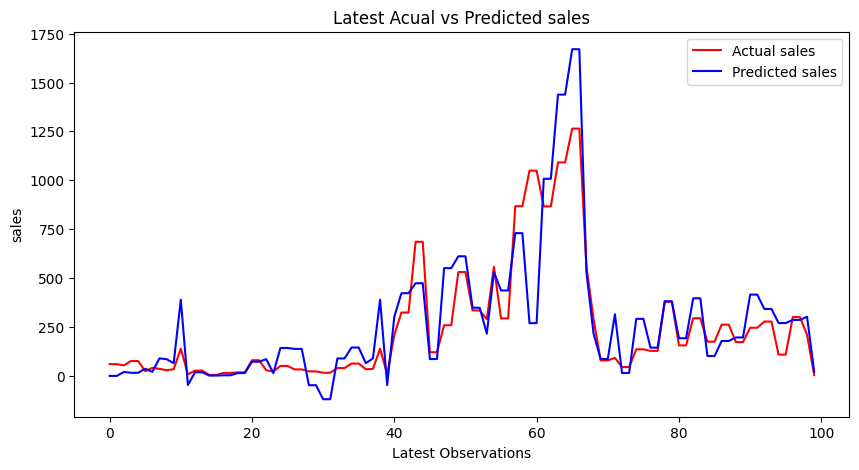

In [45]:
plt.figure(figsize=(10,5))
plt.plot(actual,label='Actual sales',color='red')
plt.plot(predicted,label='Predicted sales',color='blue')
plt.title('Latest Acual vs Predicted sales')
plt.xlabel('Latest Observations')
plt.ylabel('sales')
plt.legend()
plt.savefig(r'C:\Users\manda\Desktop\sales_pics\actual_vs_predicted.png')
plt.show()

# b. Error distributions

In [46]:
y_test

76524     530
76523     530
76531     286
76522    1023
76520     342
         ... 
95618     108
95617     300
95616     300
95644     209
95705       3
Name: sales, Length: 19142, dtype: int64

In [47]:
y_pred

array([447.25444224, 447.25444224, 341.3842739 , ..., 285.34424999,
       301.46246108,  20.92432913], shape=(19142,))

In [48]:
errors=y_test-y_pred

In [49]:
errors.round(2)

76524     82.75
76523     82.75
76531    -55.38
76522    411.91
76520    -14.30
          ...  
95618   -161.31
95617     14.66
95616     14.66
95644    -92.46
95705    -17.92
Name: sales, Length: 19142, dtype: float64

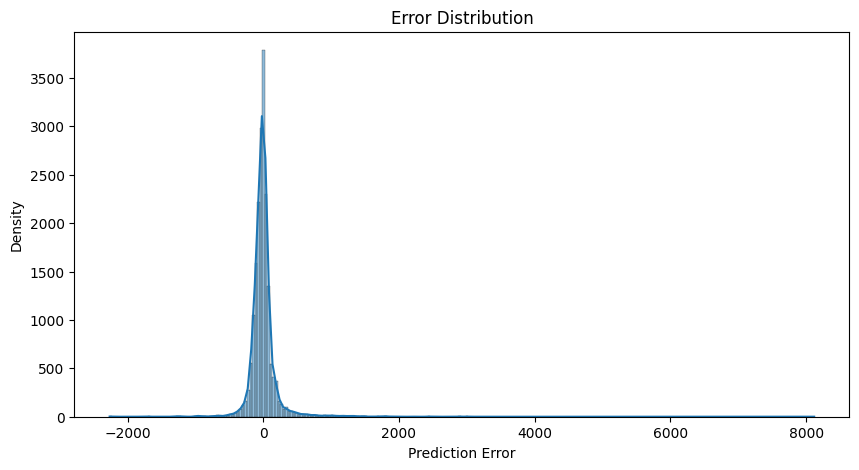

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(errors,kde=True)
plt.title('Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.savefig(r'C:\Users\manda\Desktop\sales_pics\Error Distribution.png')
plt.show()

## c. feature Importance Visualizations.

In [51]:
import pandas as pd

importance = pd.DataFrame({

    'Feature': x.columns,

    'Importance': model.coef_

})

In [52]:
importance['Importance'] = importance['Importance'].abs()

In [53]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [54]:
top_features = importance.head(10)

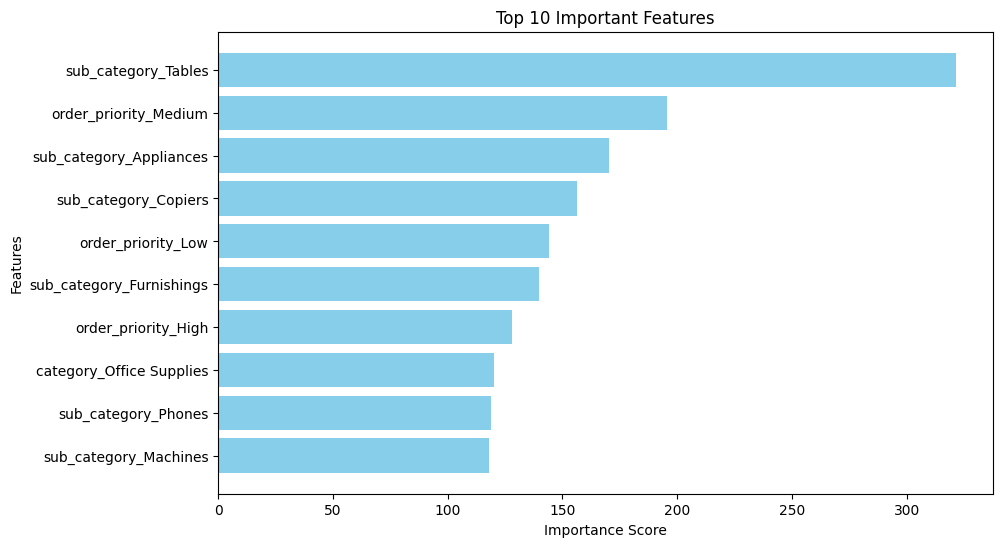

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(

    top_features['Feature'],

    top_features['Importance'],

    color='skyblue'

)

plt.gca().invert_yaxis()

plt.title('Top 10 Important Features')

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.savefig(
    r"C:\Users\manda\Desktop\sales_pics\feature_importance.png"
)

plt.show()

# d. Future Forecasting sales Trends

In [56]:
future_quantity = df['quantity'].tail(50).values
future_quantity

array([2, 3, 3, 5, 3, 3, 3, 5, 5, 9, 9, 6, 6, 3, 3, 5, 5, 3, 5, 2, 2, 7,
       1, 1, 3, 3, 6, 6, 1, 1, 4, 4, 4, 4, 4, 4, 6, 6, 3, 3, 2, 2, 4, 4,
       3, 3, 3, 3, 2, 3])

In [57]:
future_profit = df['profit'].tail(50).values
future_shipping = df['shipping_cost'].tail(50).values
future_discount = df['discount'].tail(50).values
future_profit,future_shipping,future_discount

(array([  180,     0,     0,    75,   216,    68,    68,   251,   251,
        -1195, -1195,    51,    51,    46,    46,   301,   301,   216,
           75,    35,    35,     2,    13,    13,    17,    17,    20,
           20,   166,   166,    40,    40,    88,    88,  -117,  -117,
           12,    12,     6,     6,    90,    90,   105,   105,   -19,
          -19,    84,    84,    56,     0]),
 array([ 48,  51,  51,  34,  51,  52,  52,  53,  53,  86,  86, 138, 138,
        243, 243, 253, 253,  51,  34,  25,  25,   9,   9,   9,  10,  10,
         11,  11,  11,  11,  12,  12,  13,  13,  13,  13,  15,  15,  16,
         16,  19,  19,  21,  21,  22,  22,  23,  23,   8,   0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0]))

In [58]:
future_df = pd.DataFrame({

    'quantity': df['quantity'].tail(30).values,

    'discount': df['discount'].tail(30).values,

    'profit': df['profit'].tail(30).values,

    'shipping_cost': df['shipping_cost'].tail(30).values,

    
})

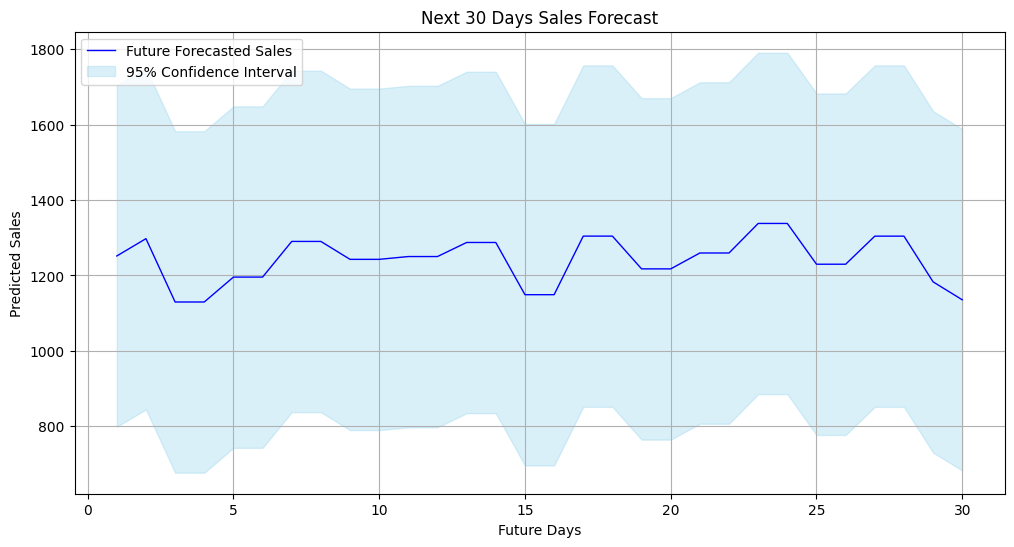

In [59]:
# ==================================
# ADD MISSING ENCODED COLUMNS
# ==================================

for col in x.columns:

    if col not in future_df.columns:

        future_df[col] = 0

# ==================================
# MATCH COLUMN ORDER
# ==================================

future_df = future_df[x.columns]

# ==================================
# PREDICT FUTURE SALES
# ==================================

future_predictions = model.predict(future_df)

# ==================================


# ==================================
# CREATE FUTURE DAYS
# ==================================

future_days = range(1,31)

# ==================================
# CREATE CONFIDENCE INTERVAL
# ==================================

upper = future_predictions + 1.96 * rmse

lower = future_predictions - 1.96* rmse

# ==================================
# PLOT FORECAST
# ==================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    future_days,

    future_predictions,

    label='Future Forecasted Sales',

    color='blue',

    linewidth=1

)

plt.fill_between(

    future_days,

    lower,

    upper,

    alpha=0.3,

    color='skyblue',

    label='95% Confidence Interval'

)

plt.title(
    'Next 30 Days Sales Forecast'
)

plt.xlabel('Future Days')

plt.ylabel('Predicted Sales')

plt.legend()

plt.grid(True)

# ==================================
# SAVE IMAGE
# ==================================

plt.savefig(

    r"C:\Users\manda\Desktop\sales_pics\future_sales_forecast.png",

    dpi=300,

    bbox_inches='tight'

)

plt.show()

# Apply Random Forest ML Models.

# a. Base Random Forest Model

In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(

    n_estimators=100,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

rf_base.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# b. Base Model Prediction

In [61]:
y_pred_base = rf_base.predict(x_test)

In [62]:
y_pred_base

array([506.43918687, 506.43918687, 374.82412331, ..., 321.5531928 ,
       143.76422388,  14.97399146], shape=(19142,))

# c. Evaluate Base Model

In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

base_mae = mean_absolute_error(
    y_test,
    y_pred_base
)
base_mse=mean_squared_error(
        y_test,
        y_pred_base
    )
base_rmse = np.sqrt(base_mse)

base_r2 = r2_score(
    y_test,
    y_pred_base
)

print("Base Random Forest")

print("MAE :", base_mae)
print("MSE :", base_mse)
print("RMSE :", base_rmse)

print("R2 :", base_r2)

Base Random Forest
MAE : 66.24224990459454
MSE : 28437.92306744599
RMSE : 168.6354739295561
R2 : 0.8734239295065843


##### Above Random forest (RMSE: 168.67 and R^2: 0.87) improves better and higher accuracy than Multiple Linear Regression(RMSE:230.23 and R^2:0.76).

# Visualizations in case of Random Forest

In [75]:
actual = pd.Series(
    y_test[-100:].values
).reset_index(drop=True)

predicted = pd.Series(
    y_pred_base[-100:]
).reset_index(drop=True)

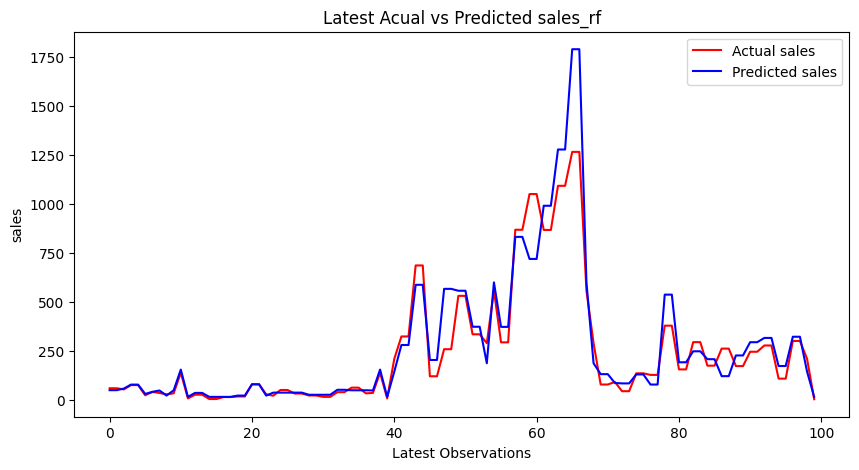

In [76]:
plt.figure(figsize=(10,5))
plt.plot(actual,label='Actual sales',color='red')
plt.plot(predicted,label='Predicted sales',color='blue')
plt.title('Latest Acual vs Predicted sales_rf')
plt.xlabel('Latest Observations')
plt.ylabel('sales')
plt.legend()
plt.savefig(r'C:\Users\manda\Desktop\sales_pics\actual_vs_predicted_rf.png')
plt.show()

In [77]:
errors=y_test-y_pred_base

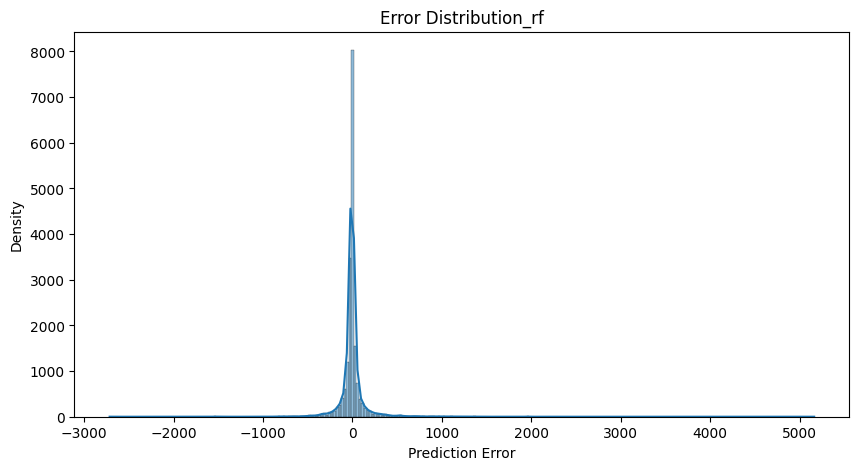

In [78]:
plt.figure(figsize=(10,5))
sns.histplot(errors,kde=True)
plt.title('Error Distribution_rf')
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.savefig(r'C:\Users\manda\Desktop\sales_pics\Error Distribution_rf.png')
plt.show()

In [81]:
importance = pd.DataFrame({

    'Feature': x.columns,

    'Importance': rf_base.feature_importances_

})

In [82]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [83]:
top_features = importance.head(10)

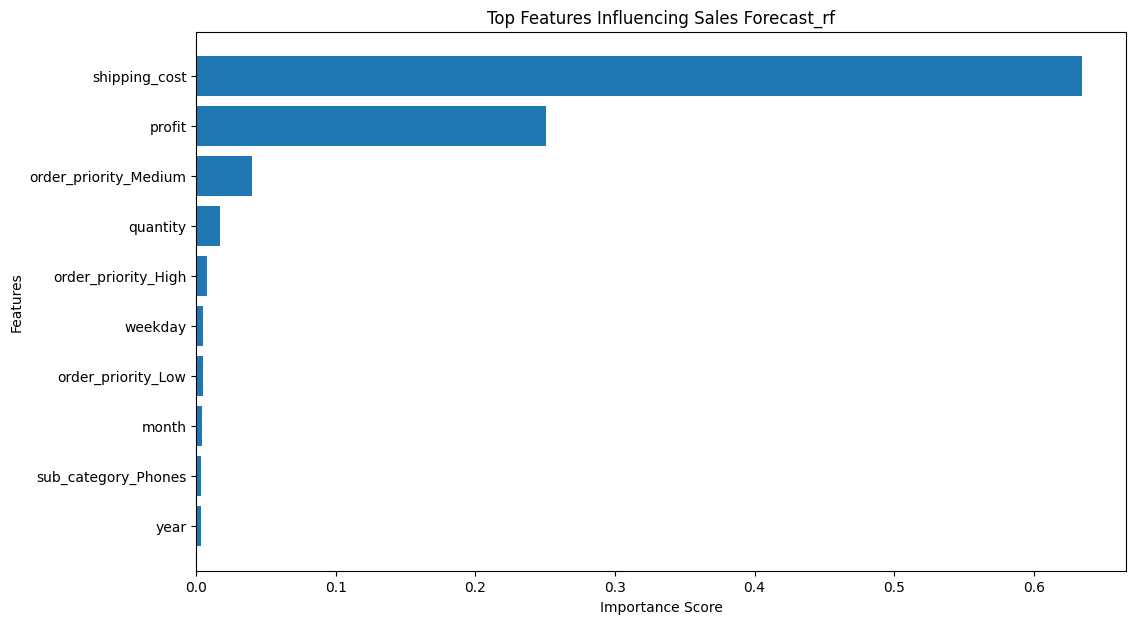

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

plt.barh(

    top_features['Feature'],

    top_features['Importance']

)

plt.gca().invert_yaxis()

plt.title('Top Features Influencing Sales Forecast_rf')

plt.xlabel('Importance Score')

plt.ylabel('Features')
plt.savefig(r'C:\Users\manda\Desktop\sales_pics\features_importance_rf.png')
plt.show()

In [89]:
 Importance=rf_base.feature_importances_

In [90]:
Importance.round(2)

array([0.02, 0.  , 0.25, 0.63, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.01, 0.  , 0.04])

In [91]:
future_df = pd.DataFrame({

    'quantity': df['quantity'].tail(30).values,

    'discount': df['discount'].tail(30).values,

    'profit': df['profit'].tail(30).values,

    'shipping_cost': df['shipping_cost'].tail(30).values,

    
})

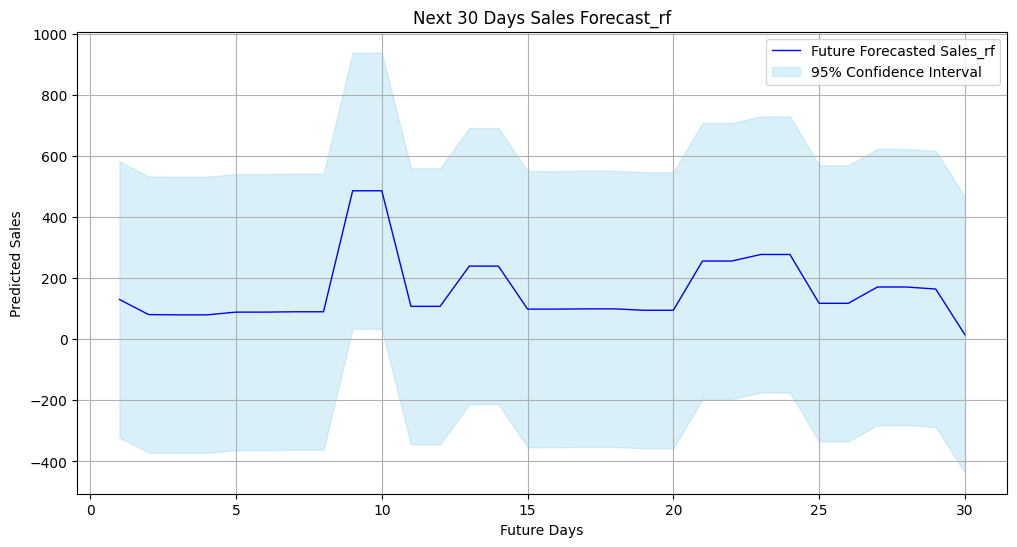

In [93]:
# ==================================
# ADD MISSING ENCODED COLUMNS
# ==================================

for col in x.columns:

    if col not in future_df.columns:

        future_df[col] = 0

# ==================================
# MATCH COLUMN ORDER
# ==================================

future_df = future_df[x.columns]

# ==================================
# PREDICT FUTURE SALES
# ==================================

future_predictions = rf_base.predict(future_df)

# ==================================


# ==================================
# CREATE FUTURE DAYS
# ==================================

future_days = range(1,31)

# ==================================
# CREATE CONFIDENCE INTERVAL
# ==================================

upper = future_predictions + 1.96 * rmse

lower = future_predictions - 1.96* rmse

# ==================================
# PLOT FORECAST
# ==================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    future_days,

    future_predictions,

    label='Future Forecasted Sales_rf',

    color='blue',

    linewidth=1

)

plt.fill_between(

    future_days,

    lower,

    upper,

    alpha=0.3,

    color='skyblue',

    label='95% Confidence Interval'

)

plt.title(
    'Next 30 Days Sales Forecast_rf'
)

plt.xlabel('Future Days')

plt.ylabel('Predicted Sales')

plt.legend()

plt.grid(True)

# ==================================
# SAVE IMAGE
# ==================================

plt.savefig(

    r"C:\Users\manda\Desktop\sales_pics\future_sales_forecast_rf.png",

    dpi=300,

    bbox_inches='tight'

)

plt.show()

# Finding best parameters for Model settings using Hyperparameter Tuning + GridsearchCV.

## Import libraries

In [64]:
from sklearn.model_selection import GridSearchCV

## Parameter Grid

In [65]:
params = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10]

}

## Grid Search

In [66]:
grid = GridSearchCV(

    RandomForestRegressor(
        random_state=42,n_jobs=-1
    ),

    params,

    cv=2,

    scoring='r2',

    n_jobs=-1

)

## Train Grid Search

In [67]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fol

## Best Parameters

In [68]:
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 200}


## Tuned Random Forest Model

In [69]:
best_rf = grid.best_estimator_

## Predict Using Tuned Model

In [70]:
y_pred_tuned = best_rf.predict(x_test)

## Evaluate Tuned Model

In [71]:
tuned_mae = mean_absolute_error(
    y_test,
    y_pred_tuned
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

tuned_r2 = r2_score(
    y_test,
    y_pred_tuned
)

print("\nTuned Random Forest")

print("MAE :", tuned_mae)

print("RMSE :", tuned_rmse)

print("R2 :", tuned_r2)


Tuned Random Forest
MAE : 66.1367097949007
RMSE : 168.52646268418107
R2 : 0.8735875220765084


## Final Comparison

In [72]:
print("\nMODEL COMPARISON")

print("Base RF R2 :", base_r2)

print("Tuned RF R2 :", tuned_r2)


MODEL COMPARISON
Base RF R2 : 0.8734239295065843
Tuned RF R2 : 0.8735875220765084


In [73]:
#A base Random Forest model was first implemented using manually selected hyperparameters. 
#To improve performance, GridSearchCV was applied for hyperparameter tuning using cross-validation.
#The tuned Random Forest model achieved improved forecasting accuracy and reduced prediction error compared to the base model.

In [74]:
#Hyperparameter tuning increased the number of estimators from 100 to 200 while retaining the optimal tree depth of 10. Only a marginal improvement in 
#performance was observed (R²: 0.8734 → 0.8736), suggesting that the initial Random Forest configuration already provided strong predictive capability.